In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("soviet_breakdown_dataset.csv")

# Create a quantitative dataset suitable for PCA: Pivot to make Years the features
gdp_pivot = df.pivot(index='Country', columns='Year', values='GDP_Per_Capita')

# Fill missing values instead of dropping whole countries.
gdp_clean = gdp_pivot.ffill(axis=1).bfill(axis=1)

# Drop any years that are completely empty for all countries to be safe
gdp_clean = gdp_clean.dropna(axis=1, how='all')

print("Data shape after cleaning:", gdp_clean.shape)

# 2. Normalize with StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(gdp_clean)

# 3. Apply PCA to get eigenvalues
pca_all = PCA()
pca_all.fit(X_scaled)

# 4. Apply PCA: 2D and 3D
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

print("PCA applied successfully!")


Data shape after cleaning: (14, 33)
PCA applied successfully!


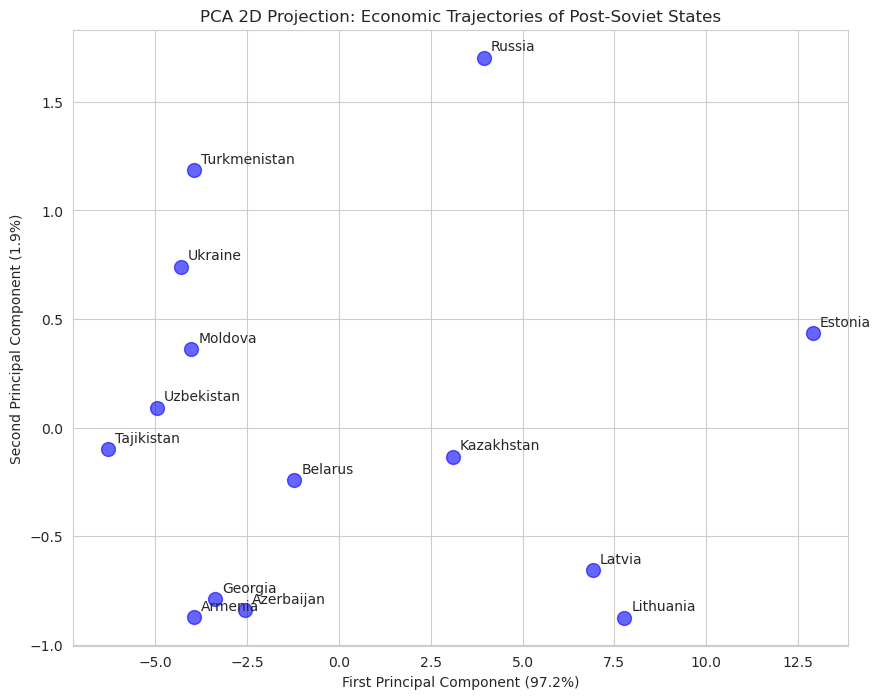

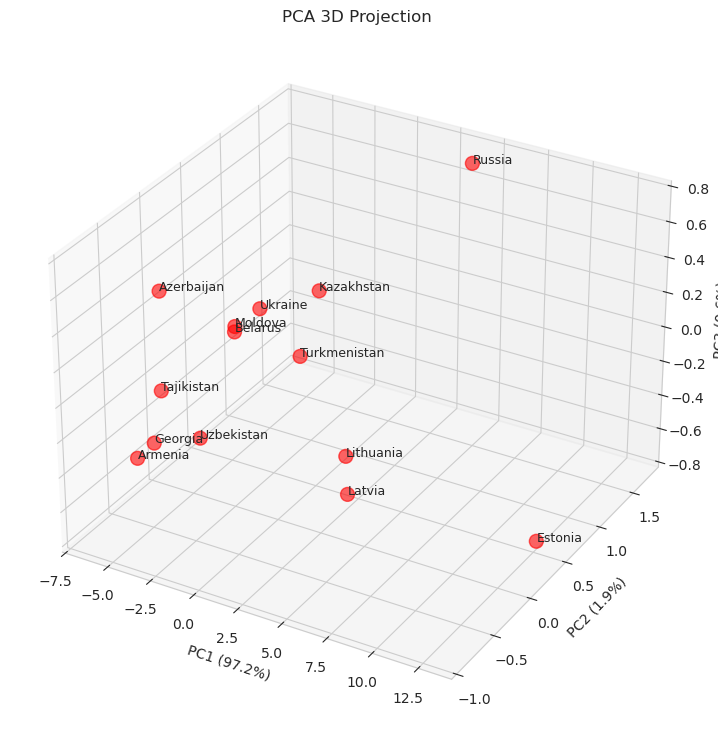

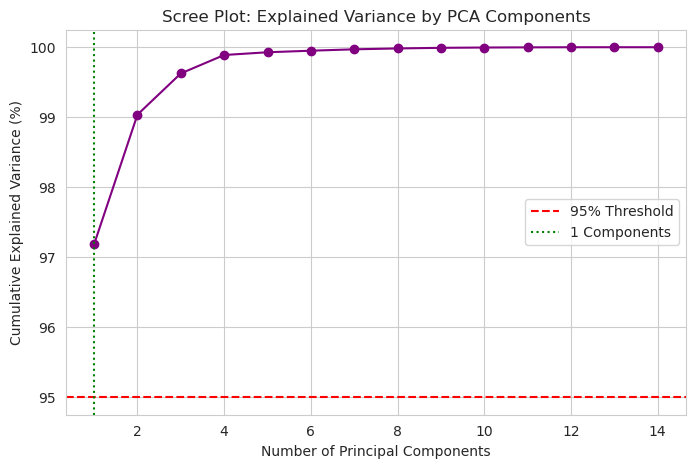


--- ANSWERS FOR THE SITE ---
Variance retained in 2D: 99.04%
Variance retained in 3D: 99.63%
Components needed for 95% variance: 1

Top 3 Eigenvalues:
Component 1: 34.5375
Component 2: 0.6586
Component 3: 0.2093


In [10]:
import seaborn as sns

# Ensure country labels align with the data
countries = gdp_clean.index
sns.set_style("whitegrid")

# --- VIZ 1: 2D PCA ---
plt.figure(figsize=(10, 8))
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c='blue', alpha=0.6, s=100)
for i, txt in enumerate(countries):
    # Add a slight offset so labels don't cover the dots
    plt.annotate(txt, (X_pca_2[i, 0], X_pca_2[i, 1]), xytext=(5, 5), textcoords='offset points')
plt.xlabel(f'First Principal Component ({pca_all.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Second Principal Component ({pca_all.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA 2D Projection: Economic Trajectories of Post-Soviet States')
plt.savefig('pca_2d.png', dpi=300, bbox_inches='tight')
plt.show()

# --- VIZ 2: 3D PCA ---
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3[:, 0], X_pca_3[:, 1], X_pca_3[:, 2], c='red', s=100, alpha=0.6)
for i, txt in enumerate(countries):
    ax.text(X_pca_3[i, 0], X_pca_3[i, 1], X_pca_3[i, 2], txt, size=9)
ax.set_xlabel(f'PC1 ({pca_all.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_all.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca_all.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title('PCA 3D Projection')
plt.savefig('pca_3d.png', dpi=300, bbox_inches='tight')
plt.show()

# --- VIZ 3: Scree Plot (Cumulative Variance) ---
cumulative_variance = np.cumsum(pca_all.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance * 100, marker='o', linestyle='-', color='purple')
plt.axhline(y=95, color='r', linestyle='--', label='95% Threshold')
plt.axvline(x=n_components_95, color='g', linestyle=':', label=f'{n_components_95} Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Scree Plot: Explained Variance by PCA Components')
plt.legend()
plt.savefig('pca_variance.png', dpi=300, bbox_inches='tight')
plt.show()

# --- ANSWERS FOR SITE  ---
print("\n--- ANSWERS FOR THE SITE ---")
print(f"Variance retained in 2D: {sum(pca_2.explained_variance_ratio_)*100:.2f}%")
print(f"Variance retained in 3D: {sum(pca_3.explained_variance_ratio_)*100:.2f}%")
print(f"Components needed for 95% variance: {n_components_95}")
print("\nTop 3 Eigenvalues:")
for i, eigen in enumerate(pca_all.explained_variance_[:3]):
    print(f"Component {i+1}: {eigen:.4f}")


Saved clustering_raw_labeled.csv
Saved clustering_unlabeled_quant.csv
Variance retained in 3D: 99.63%


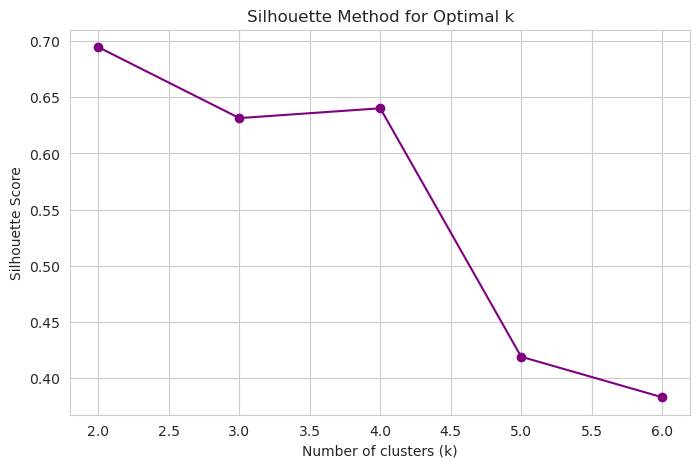

Saved silhouette_plot.png


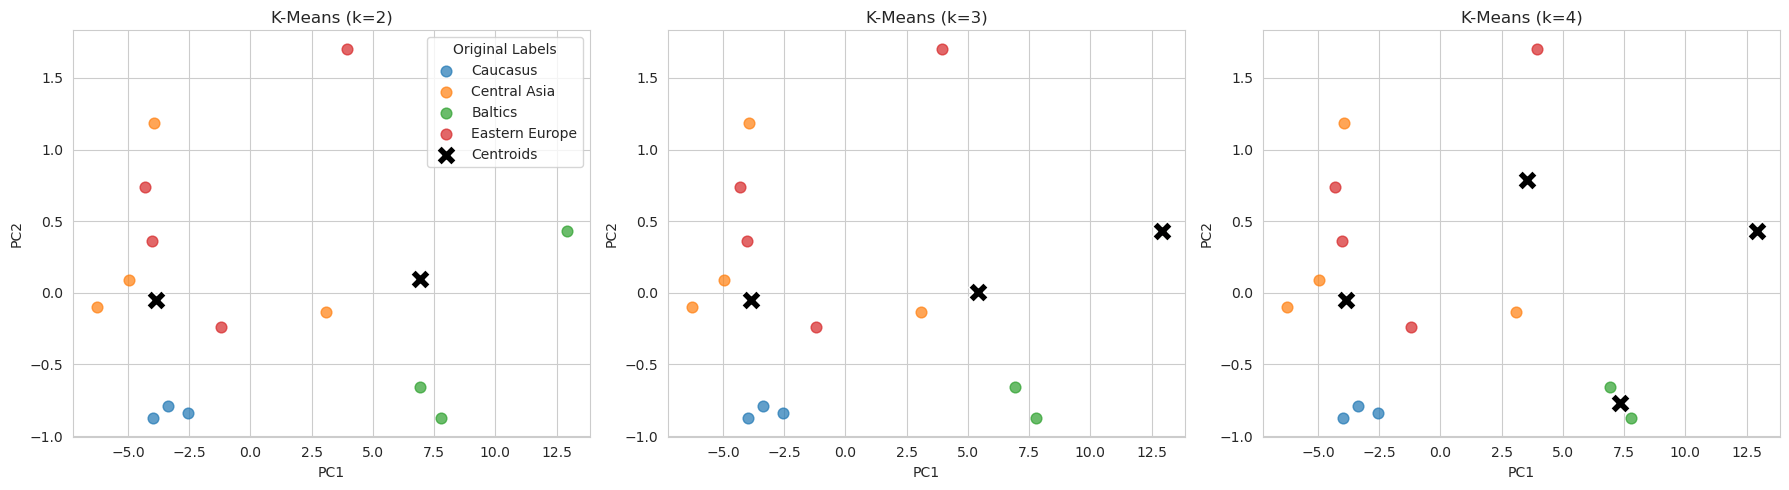

Saved kmeans_plots.png


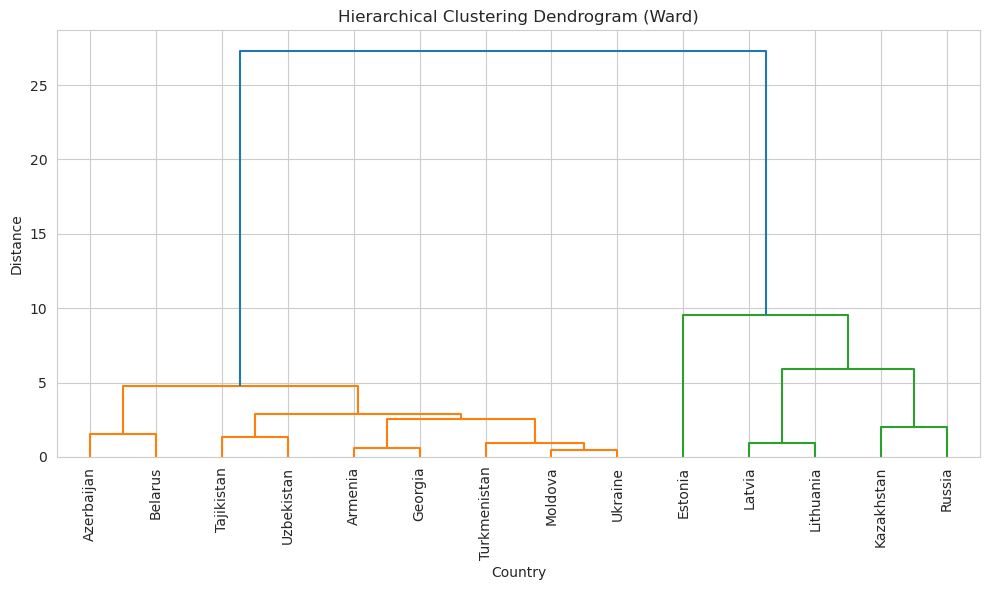

Saved dendrogram.png


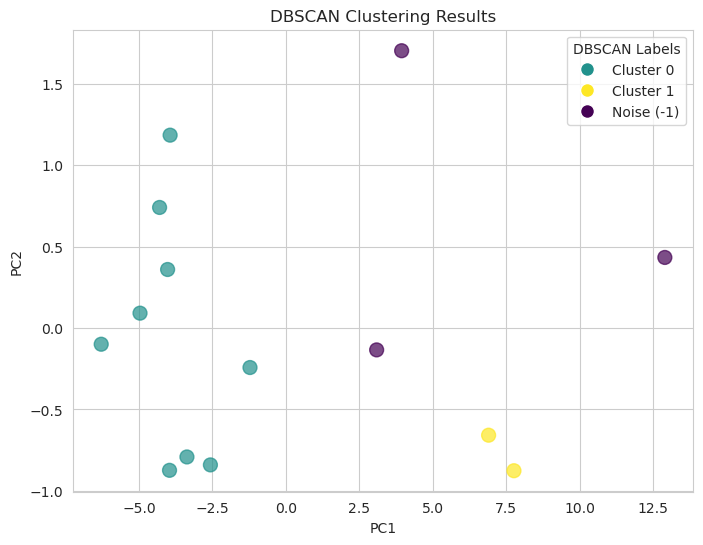

Saved dbscan_plot.png


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. DATA PREP & CSV GENERATION
# ==========================================

df = pd.read_csv("soviet_breakdown_dataset.csv")

# Create the 'Region' label column
regions_map = {
    'Estonia': 'Baltics', 'Latvia': 'Baltics', 'Lithuania': 'Baltics',
    'Russia': 'Eastern Europe', 'Ukraine': 'Eastern Europe', 'Belarus': 'Eastern Europe', 'Moldova': 'Eastern Europe',
    'Kazakhstan': 'Central Asia', 'Uzbekistan': 'Central Asia', 'Turkmenistan': 'Central Asia', 'Kyrgyzstan': 'Central Asia', 'Tajikistan': 'Central Asia',
    'Armenia': 'Caucasus', 'Azerbaijan': 'Caucasus', 'Georgia': 'Caucasus'
}
df['Region'] = df['Country'].map(regions_map)

# Pivot to wide format
df_wide = df.pivot(index=['Country', 'Region'], columns='Year', values='GDP_Per_Capita').reset_index()

# Save the labeled dataset for your website screenshot
df_wide.to_csv('clustering_raw_labeled.csv', index=False)
print("Saved clustering_raw_labeled.csv")

# Extract labels for later plotting
labels_country = df_wide['Country'].values
labels_region = df_wide['Region'].values

# Keep only quantitative data and fill gaps
X_quant = df_wide.drop(columns=['Country', 'Region'])
X_quant = X_quant.ffill(axis=1).bfill(axis=1)
X_quant = X_quant.dropna(axis=1, how='all')

# Save the unlabeled quantitative dataset for your website screenshot
X_quant.to_csv('clustering_unlabeled_quant.csv', index=False)
print("Saved clustering_unlabeled_quant.csv")

# Normalize and apply PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_quant)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
print(f"Variance retained in 3D: {sum(pca.explained_variance_ratio_)*100:.2f}%")


# ==========================================
# 2. K-MEANS & SILHOUETTE PLOT
# ==========================================
silhouette_scores = []
K_range = [2, 3, 4, 5, 6]

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    preds = kmeans.fit_predict(X_pca)
    silhouette_scores.append(silhouette_score(X_pca, preds))

# ---> PLOT 1: Silhouette Plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o', linestyle='-', color='purple')
plt.title('Silhouette Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.savefig('silhouette_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved silhouette_plot.png")

# K-Means Plots (k=2, 3, 4) colored by original labels
chosen_k = [2, 3, 4]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
unique_regions = list(set(labels_region))

for i, k in enumerate(chosen_k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_pca)
    centroids = kmeans.cluster_centers_
    
    ax = axes[i]
    for region in unique_regions:
        idx = (labels_region == region)
        ax.scatter(X_pca[idx, 0], X_pca[idx, 1], label=region, alpha=0.7, s=60)
    
    ax.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, label='Centroids', edgecolors='white')
    ax.set_title(f'K-Means (k={k})')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    if i == 0:
        ax.legend(title='Original Labels')

plt.tight_layout()
plt.savefig('kmeans_plots.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved kmeans_plots.png")


# ==========================================
# 3. HIERARCHICAL CLUSTERING (DENDROGRAM)
# ==========================================

plt.figure(figsize=(10, 6))
Z = linkage(X_pca, method='ward')
dendrogram(Z, labels=labels_country, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram (Ward)')
plt.xlabel('Country')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved dendrogram.png")


# ==========================================
# 4. DBSCAN CLUSTERING
# ==========================================

dbscan = DBSCAN(eps=2.0, min_samples=2)
db_clusters = dbscan.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=db_clusters, cmap='viridis', s=100, alpha=0.7)
plt.title('DBSCAN Clustering Results')
plt.xlabel('PC1')
plt.ylabel('PC2')

# Create a legend
unique_db_labels = set(db_clusters)
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(l)), 
                              markersize=10, label=f'Cluster {l}' if l != -1 else 'Noise (-1)') 
                   for l in unique_db_labels]
plt.legend(handles=legend_elements, title="DBSCAN Labels", loc='best')

plt.savefig('dbscan_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved dbscan_plot.png")


In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Silhouette Method to find optimal k
K_range = [2, 3, 4, 5, 6]
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    preds = kmeans.fit_predict(X_pca)
    print(f"For k={k}, Silhouette Score: {silhouette_score(X_pca, preds):.3f}")


For k=2, Silhouette Score: 0.695
For k=3, Silhouette Score: 0.631
For k=4, Silhouette Score: 0.640
For k=5, Silhouette Score: 0.430
For k=6, Silhouette Score: 0.388


In [8]:
pip install mlxtend networkx

  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached scipy-1.17.1-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached numpy-2.4.2-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.1-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached scikit_learn-1.8.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached matplotlib-3.10.8-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached mlxtend-0.24.0-py3-none-any.whl (1.4 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached matplotlib-3.10.8-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.7 MB)
Using cached numpy-2.4.2-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.9 MB)
Using cached pandas-3.0.1-cp311-cp311

Saved arm_transaction_data.csv

--- TOP 15 BY SUPPORT ---
             antecedents           consequents   support  confidence      lift
11            (GDP_High)            (Recovery)  0.304786    0.937984  1.237142
15            (Mil_High)            (Recovery)  0.269521    0.804511  1.061100
17             (Mil_Med)            (Recovery)  0.256927    0.778626  1.026958
10      (Eastern Europe)            (Recovery)  0.251889    0.769231  1.014567
14             (GDP_Med)            (Recovery)  0.246851    0.765625  1.009811
16             (Mil_Low)            (Recovery)  0.231738    0.691729  0.912347
1              (Baltics)            (GDP_High)  0.198992    0.822917  2.532542
0             (GDP_High)             (Baltics)  0.198992    0.612403  2.532542
6             (Caucasus)            (Recovery)  0.188917    0.797872  1.052343
3              (Baltics)            (Recovery)  0.188917    0.781250  1.030419
26   (GDP_High, Baltics)            (Recovery)  0.181360    0.911392  1.2

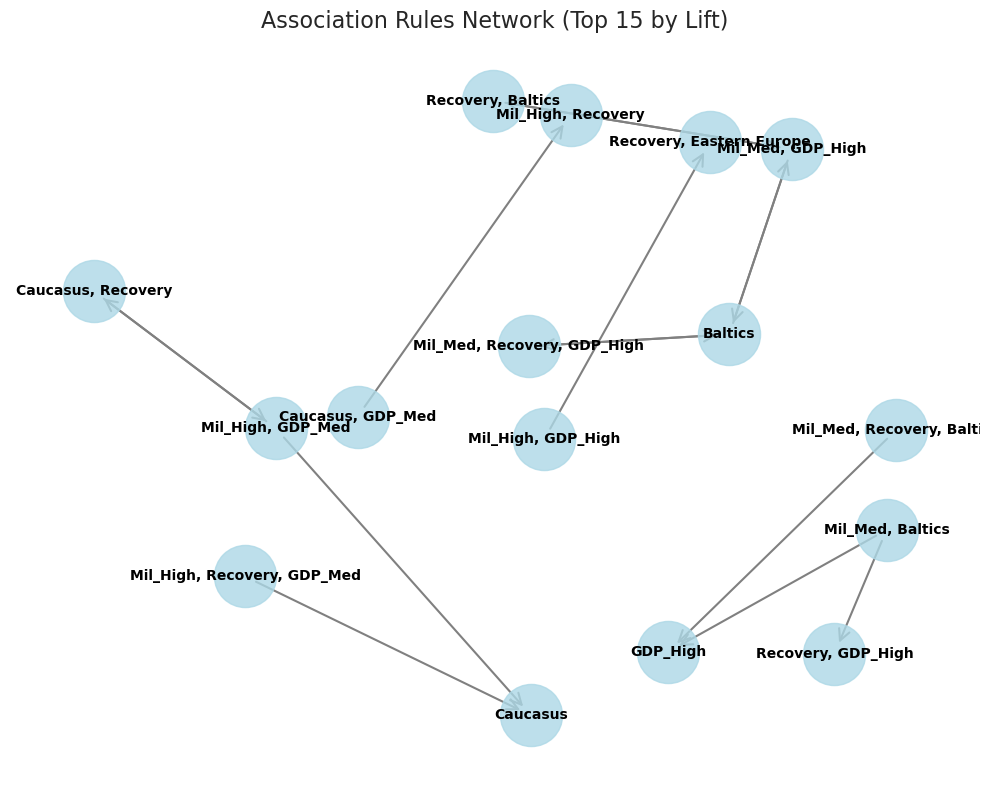

Saved arm_network_plot.png


In [9]:
import pandas as pd
import numpy as np
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import networkx as nx
import matplotlib.pyplot as plt

# ==========================================
# 1. DATA PREP: CONVERT TO TRANSACTIONS
# ==========================================
df = pd.read_csv("soviet_breakdown_dataset.csv")

# Re-add Region
regions_map = {
    'Estonia': 'Baltics', 'Latvia': 'Baltics', 'Lithuania': 'Baltics',
    'Russia': 'Eastern Europe', 'Ukraine': 'Eastern Europe', 'Belarus': 'Eastern Europe', 'Moldova': 'Eastern Europe',
    'Kazakhstan': 'Central Asia', 'Uzbekistan': 'Central Asia', 'Turkmenistan': 'Central Asia', 'Kyrgyzstan': 'Central Asia', 'Tajikistan': 'Central Asia',
    'Armenia': 'Caucasus', 'Azerbaijan': 'Caucasus', 'Georgia': 'Caucasus'
}
df['Region'] = df['Country'].map(regions_map)

# Discretize (Binning) Quantitative Data into 3 equal-sized buckets
df['GDP_Level'] = pd.qcut(df['GDP_Per_Cadrpita'], q=3, labels=['GDP_Low', 'GDP_Med', 'GDP_High'])
df['Mil_Burden'] = pd.qcut(df['Military_Exp_Percent_GDP'], q=3, labels=['Mil_Low', 'Mil_Med', 'Mil_High'])

# Create Transactions (List of lists) - Drop 'Country' and 'Year' so it is purely unlabeled 
transactions = df[['Region', 'Period', 'GDP_Level', 'Mil_Burden']].astype(str).values.tolist()

# Save the transaction dataset for your website screenshot
with open('arm_transaction_data.csv', 'w') as f:
    for t in transactions:
        f.write(','.join(t) + '\n')
print("Saved arm_transaction_data.csv")

# ==========================================
# 2. RUN APRIORI ALGORITHM
# ==========================================
# One-hot encode the transaction list
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_tx = pd.DataFrame(te_ary, columns=te.columns_)

# Apriori: Use a minimum support of 5% (0.05)
frequent_itemsets = apriori(df_tx, min_support=0.05, use_colnames=True)

# Association Rules: Use a minimum confidence of 50% (0.5)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

# ==========================================
# 3. PRINT RESULTS FOR YOUR WEBSITE
# ==========================================
print("\n--- TOP 15 BY SUPPORT ---")
print(rules.sort_values('support', ascending=False)[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15))

print("\n--- TOP 15 BY CONFIDENCE ---")
print(rules.sort_values('confidence', ascending=False)[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15))

print("\n--- TOP 15 BY LIFT ---")
print(rules.sort_values('lift', ascending=False)[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15))

# ==========================================
# 4. NETWORK VISUALIZATION
# ==========================================
# Get top 15 rules by Lift 
top_rules = rules.sort_values('lift', ascending=False).head(15)

plt.figure(figsize=(10, 8))
G = nx.DiGraph()

for i, row in top_rules.iterrows():
    # Convert frozensets to strings
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    # Add directed edge with weight = lift
    G.add_edge(ant, con, weight=row['lift'])

pos = nx.spring_layout(G, k=1.5)
# Draw nodes and labels
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue', alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")
# Draw edge
edges = nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=20, edge_color='gray', width=1.5)

plt.title('Association Rules Network (Top 15 by Lift)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.savefig('arm_network_plot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved arm_network_plot.png")
